In [35]:
import pandas as pd
import numpy as np
import math

In [9]:
raw_df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")
raw_df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [10]:
raw_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
df_X = raw_df.drop('target',axis=1)
target_df = raw_df['target']

In [16]:
X = df_X.to_numpy()
Y = target_df.to_numpy()

In [ ]:
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]
len(X_train), len(Y_train)

(820, 820)

## helpers

In [54]:
def sigmoid(x):
     return 1 / (1 + np.exp(-x))

def get_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def compute_single_loss(y_true, a_pred):
    """
    Implements: -(y*log(a) + (1-y)*log(1-a))
    """
    # Clip a_pred to be slightly away from 0 and 1
    # This replaces the need to manually add 1e-15 everywhere
    a_pred = np.clip(a_pred, 1e-15, 1 - 1e-15)
    
    loss = -(y_true * np.log(a_pred) + (1 - y_true) * np.log(1 - a_pred))
    return loss

## W LL

In [42]:
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)

In [84]:
n_count = len(X_train[0])
n_samples = len(X_train)

w = np.zeros(n_count)
b = 0

n_count, n_samples

(13, 820)

In [85]:
lr = 0.5
costs = []

In [86]:
for i in range(100):
    
    J_total = 0 
    dw_total = np.zeros(13)
    db_total = 0

    for k in range(n_samples):
        # 1. Forward Pass
        z_k = np.dot(X_train[k], w) + b
        a_k = sigmoid(z_k)
        
        # 2. Accumulate Loss (J) 
        # Using 1e-15 to prevent log(0) errors
        J_total +=  compute_single_loss(Y_train[k], a_k)
        
        # 3. Accumulate Gradients (dw, db)
        dz_k = a_k - Y_train[k]
        dw_total += X_train[k] * dz_k 
        db_total += dz_k
        

    cost = J_total / n_samples
    w -= lr * (dw_total / n_samples)
    b -= lr * (db_total / n_samples)
    
    costs.append(cost)

In [87]:
cost

np.float64(0.3273440065089137)

In [88]:
X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)

In [89]:
z_test = np.dot(X_test, w) + b
probabilities = sigmoid(z_test)

predictions = (probabilities > 0.5).astype(int)

In [90]:
predictions

array([0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0])

In [91]:
get_accuracy(predictions, Y_test)

np.float64(0.7902439024390244)

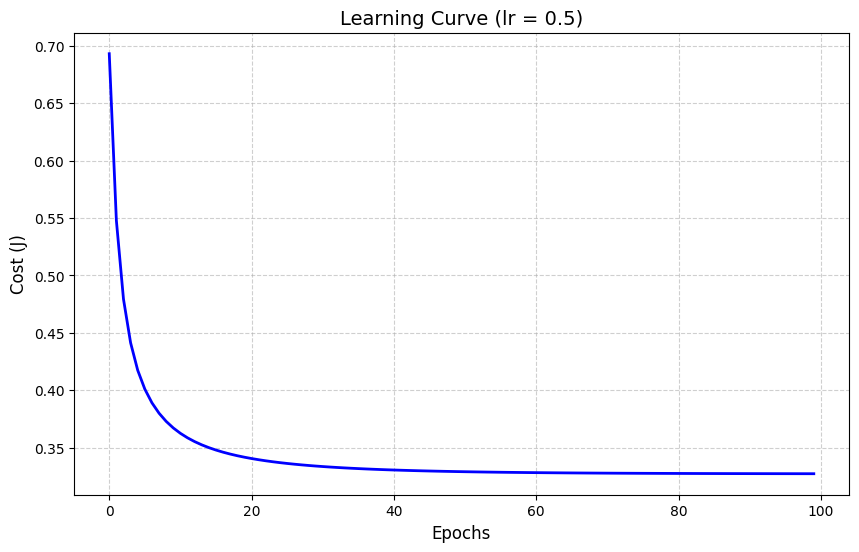

In [92]:
import matplotlib.pyplot as plt

def plot_learning_curve(costs, learning_rate):
    """
    Plots the cost J over iterations to visualize model convergence.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(costs, color='blue', linewidth=2)
    
    # Adding labels and title
    plt.ylabel('Cost (J)', fontsize=12)
    plt.xlabel('Epochs', fontsize=12)
    plt.title(f'Learning Curve (lr = {learning_rate})', fontsize=14)
    
    # Adding a grid for better readability
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

# --- Usage ---
# Assuming 'costs' is the list you populated during your 1000 epochs
plot_learning_curve(costs, lr)
